# YOLO: Real-Time Object Detection

## What is Object Detection?

Object detection combines **classification** (what?) with **localization** (where?).

| Task | Output | Example |
|------|--------|--------|
| **Classification** | Single label | "cat" |
| **Localization** | Label + 1 bounding box | "cat" at (x, y, w, h) |
| **Object Detection** | Multiple labels + boxes | "cat" at (...), "dog" at (...) |
| **Segmentation** | Pixel-level masks | Each pixel labeled |

## YOLO: You Only Look Once

**YOLO** revolutionized object detection by treating it as a single regression problem, making real-time detection possible.

### Evolution

| Version | Year | Key Innovation |
|---------|------|----------------|
| YOLOv1 | 2016 | Single-pass detection |
| YOLOv2/9000 | 2017 | Batch normalization, anchors |
| YOLOv3 | 2018 | Multi-scale predictions |
| YOLOv4 | 2020 | CSPDarknet backbone |
| YOLOv5 | 2020 | PyTorch, easy training |
| YOLOv8 | 2023 | Ultralytics, anchor-free |
| YOLOv11 | 2024 | Latest Ultralytics version |

We'll use **Ultralytics YOLOv8/v11** - the most user-friendly implementation.

## Installation

```bash
pip install ultralytics
# or
uv add ultralytics
# or
conda install ultralytics
```

In [ ]:
import os
# Define output directory for YOLO runs (absolute path to avoid issues)
project_dir = os.path.abspath('outputs/yolo_outputs')
if not os.path.exists(project_dir):
    os.makedirs(project_dir)

from pathlib import Path
from ultralytics import YOLO
from ultralytics import settings

# Configure ultralytics to store models in a local subfolder
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)
settings.update({"weights_dir": str(MODELS_DIR.resolve())})

## Loading Pre-trained Models

Ultralytics provides pre-trained models for different tasks:

| Model | Task | Description |
|-------|------|-------------|
| `yolov8n.pt` | Detection | Nano (fastest, least accurate) |
| `yolov8s.pt` | Detection | Small |
| `yolov8m.pt` | Detection | Medium |
| `yolov8l.pt` | Detection | Large |
| `yolov8x.pt` | Detection | Extra-large (slowest, most accurate) |
| `yolov8n-seg.pt` | Segmentation | Instance segmentation |
| `yolov8n-pose.pt` | Pose | Human pose estimation |
| `yolov8n-cls.pt` | Classification | Image classification |

In [ ]:
# Load a pre-trained detection model (downloads to models/)
model = YOLO(MODELS_DIR / "yolov8n.pt")  # Nano model for speed

print(f"Model: {model.model_name}")
print(f"Classes: {len(model.names)} COCO classes")

Model: models/yolov8n.pt
Classes: 80 COCO classes


## Basic Inference

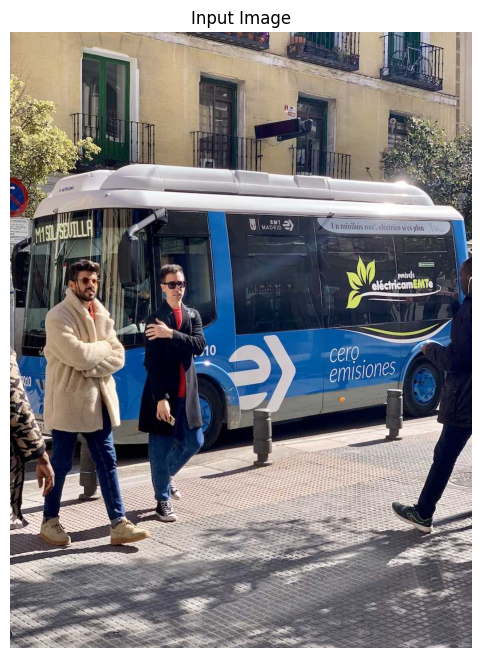

In [ ]:
import urllib.request
import os
import matplotlib.pyplot as plt
import cv2

# Download a sample image
sample_url = "https://ultralytics.com/images/bus.jpg"
sample_path = os.path.join(project_dir, "sample_bus.jpg")

if not os.path.exists(sample_path):
    urllib.request.urlretrieve(sample_url, sample_path)

def visualize_image(image, titlet):
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(titlet)
    plt.show()

visualize_image(cv2.imread(sample_path), "Input Image")

In [ ]:
# Run inference.
# model() returns a list — one Results object per input image.
results = model(sample_path, save=True, project=project_dir)

result = results[0]  # first (and only) image

print(f"Found {len(result.boxes)} objects")
for box in result.boxes:
    cls_id = int(box.cls[0])          # class index
    conf = float(box.conf[0])         # confidence score 0–1
    xyxy = box.xyxy[0].cpu().numpy()  # bounding box in pixel coords
    print(f"  {model.names[cls_id]}: {conf:.2f} at {xyxy}")


image 1/1 /media/NOCTURNOEXTRA/Alejandro/wip-clase/PIA-SAA/example_repos/computer-vision-tools/outputs/yolo_outputs/sample_bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 68.8ms
Speed: 3.9ms preprocess, 68.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /media/NOCTURNOEXTRA/Alejandro/wip-clase/PIA-SAA/example_repos/computer-vision-tools/outputs/yolo_outputs/predict17
Found 6 objects
  bus: 0.87 at [     22.871      231.28         805      756.84]
  person: 0.87 at [      48.55      398.55      245.35       902.7]
  person: 0.85 at [     669.47      392.19      809.72      877.04]
  person: 0.83 at [     221.52       405.8      344.97      857.54]
  person: 0.26 at [          0      550.53      63.007      873.44]
  stop sign: 0.26 at [   0.058167      254.46      32.557      324.87]


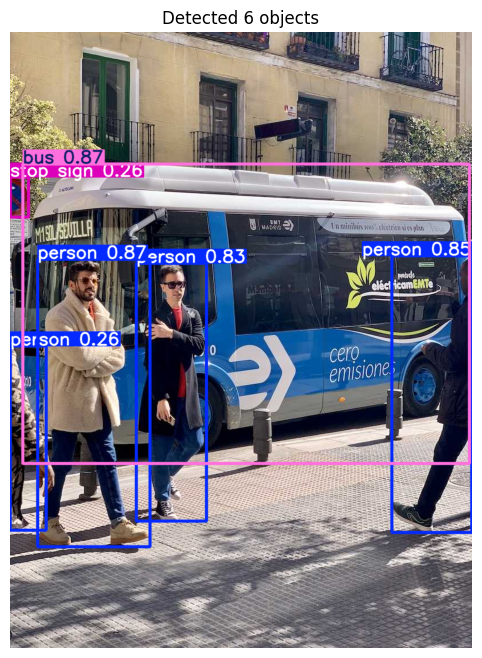

In [ ]:
# Visualize with built-in plotting
annotated = result.plot()  # Returns BGR image with annotations

visualize_image(annotated, f"Detected {len(result.boxes)} objects")

## Understanding Results

Each detection includes:
- **Bounding box** (`xyxy` or `xywh` format)
- **Confidence score** (0-1)
- **Class ID** (maps to `model.names`)

In [ ]:
# Three coordinate formats — choose the one your downstream code expects.
# xyxy  : (x1, y1, x2, y2) pixel coords  — top-left and bottom-right corners.
# xywh  : (cx, cy, w, h) pixel coords    — centre + size.
# xywhn : (cx, cy, w, h) normalised 0–1  — matches YOLO label file format.
for box in result.boxes:
    print(f"xyxy  (top-left, bottom-right): {box.xyxy[0].cpu().numpy()}")
    print(f"xywh  (centre, width, height):  {box.xywh[0].cpu().numpy()}")
    print(f"xywhn (normalised centre+size): {box.xywhn[0].cpu().numpy()}")
    break

xyxy  (top-left, bottom-right): [     22.871      231.28         805      756.84]
xywh  (centre, width, height):  [     413.94      494.06      782.13      525.56]
xywhn (normalised centre+size): [    0.51103     0.45746     0.96559     0.48663]


## Inference on Multiple Sources

In [ ]:
# From URL
results = model("https://ultralytics.com/images/zidane.jpg", save=True, project=project_dir)

# From NumPy array
img_array = cv2.imread(sample_path)
results = model(img_array, save=True, project=project_dir)

# From list of images
results = model([sample_path, sample_path], save=True, project=project_dir)  # Batch inference
print(f"Processed {len(results)} images")


Found https://ultralytics.com/images/zidane.jpg locally at zidane.jpg
image 1/1 /media/NOCTURNOEXTRA/Alejandro/wip-clase/PIA-SAA/example_repos/computer-vision-tools/zidane.jpg: 384x640 2 persons, 1 tie, 55.3ms
Speed: 2.2ms preprocess, 55.3ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /media/NOCTURNOEXTRA/Alejandro/wip-clase/PIA-SAA/example_repos/computer-vision-tools/outputs/yolo_outputs/predict18

0: 640x480 4 persons, 1 bus, 1 stop sign, 55.2ms
Speed: 2.2ms preprocess, 55.2ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /media/NOCTURNOEXTRA/Alejandro/wip-clase/PIA-SAA/example_repos/computer-vision-tools/outputs/yolo_outputs/predict19

0: 640x480 4 persons, 1 bus, 1 stop sign, 58.2ms
1: 640x480 4 persons, 1 bus, 1 stop sign, 58.2ms
Speed: 2.4ms preprocess, 58.2ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /media/NOCTURNOEXTRA/Alejandro/wip-clase/PIA-SAA/example_repos/com

## Filtering Detections

In [ ]:
# conf — minimum confidence; detections below this are discarded.
results = model(sample_path, conf=0.5, save=True, project=project_dir)

# classes — whitelist of class IDs (COCO: 0=person, 2=car, 16=dog, ...).
# All other classes are silently dropped even if their confidence is high.
results = model(sample_path, classes=[0, 2], save=True, project=project_dir)

# iou — IoU threshold used inside NMS; lower = more aggressive suppression.
results = model(sample_path, iou=0.5, save=True, project=project_dir)


image 1/1 /media/NOCTURNOEXTRA/Alejandro/wip-clase/PIA-SAA/example_repos/computer-vision-tools/outputs/yolo_outputs/sample_bus.jpg: 640x480 3 persons, 1 bus, 65.1ms
Speed: 4.9ms preprocess, 65.1ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /media/NOCTURNOEXTRA/Alejandro/wip-clase/PIA-SAA/example_repos/computer-vision-tools/outputs/yolo_outputs/predict21

image 1/1 /media/NOCTURNOEXTRA/Alejandro/wip-clase/PIA-SAA/example_repos/computer-vision-tools/outputs/yolo_outputs/sample_bus.jpg: 640x480 4 persons, 213.5ms
Speed: 2.0ms preprocess, 213.5ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /media/NOCTURNOEXTRA/Alejandro/wip-clase/PIA-SAA/example_repos/computer-vision-tools/outputs/yolo_outputs/predict22

image 1/1 /media/NOCTURNOEXTRA/Alejandro/wip-clase/PIA-SAA/example_repos/computer-vision-tools/outputs/yolo_outputs/sample_bus.jpg: 640x480 4 persons, 82.1ms
Speed: 9.0ms preprocess, 82.1ms inference, 1.2ms postp

## Video Inference

YOLO can process videos in real-time.

In [ ]:
# Download sample video
video_url = "https://github.com/ultralytics/assets/releases/download/v0.0.0/decelera_portrait_min.mov"
video_path = os.path.join(project_dir, "outputs/sample_video.mov")

if not os.path.exists(video_path):
    try:
        urllib.request.urlretrieve(video_url, video_path)
        print("Downloaded sample video")
    except:
        print("Could not download video, skipping video demo")
        video_path = None

Could not download video, skipping video demo


In [ ]:
if video_path and os.path.exists(video_path):
    # stream=True: model() becomes a generator — frames are decoded and processed
    # one at a time instead of loading the whole video into memory at once.
    # Essential for long videos or RAM-constrained environments.
    results = model(video_path, stream=True, save=True, project=project_dir)

    frame_count = 0
    for result in results:
        frame_count += 1
        if frame_count >= 5:  # process only first 5 frames for this demo
            break

    print(f"Processed {frame_count} frames")

## Different YOLO Tasks

In [ ]:
# Instance Segmentation
seg_model = YOLO(MODELS_DIR / 'yolov8n-seg.pt')
seg_results = seg_model(sample_path, save=True, project=project_dir)

# Access masks
if seg_results[0].masks is not None:
    print(f"Segmentation masks shape: {seg_results[0].masks.data.shape}")


image 1/1 /media/NOCTURNOEXTRA/Alejandro/wip-clase/PIA-SAA/example_repos/computer-vision-tools/outputs/yolo_outputs/sample_bus.jpg: 640x480 4 persons, 1 bus, 1 skateboard, 89.5ms
Speed: 3.1ms preprocess, 89.5ms inference, 4.7ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /media/NOCTURNOEXTRA/Alejandro/wip-clase/PIA-SAA/example_repos/computer-vision-tools/outputs/yolo_outputs/predict24
Segmentation masks shape: torch.Size([6, 640, 480])


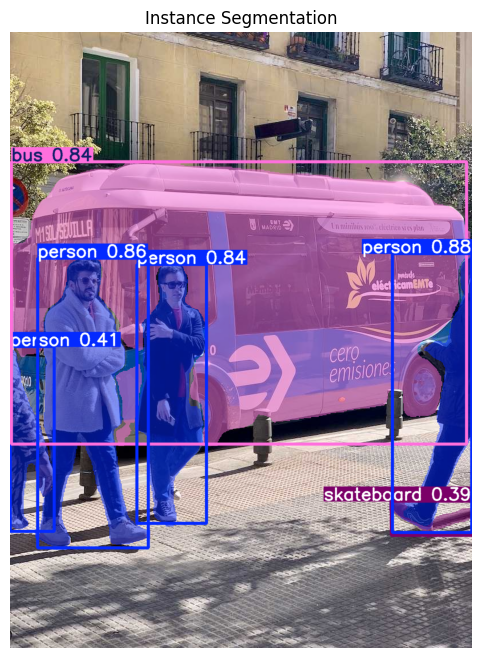

In [ ]:
# Visualize segmentation
seg_annotated = seg_results[0].plot()

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(seg_annotated, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Instance Segmentation")
plt.show()

## Model Comparison

In [ ]:
import time

models_to_compare = ['yolov8n.pt', 'yolov8s.pt']

for model_name in models_to_compare:
    model = YOLO(MODELS_DIR / model_name)
    
    # Warmup
    _ = model(sample_path, verbose=False)
    
    # Time inference
    start = time.time()
    for _ in range(10):
        _ = model(sample_path, verbose=False)
    elapsed = (time.time() - start) / 10 * 1000
    
    print(f"{model_name}: {elapsed:.1f}ms per image")

yolov8n.pt: 83.7ms per image
yolov8s.pt: 130.1ms per image


## Exporting Models

YOLO models can be exported to various formats for deployment.

In [ ]:
# Export the model to a portable format.
# Use the format that matches your deployment target:
#   onnx        — cross-platform (CPU/GPU); works with OpenCV DNN, ONNX Runtime, etc.
#   torchscript — TorchScript for C++ or mobile PyTorch deployments.
#   coreml      — Apple Neural Engine (iOS/macOS).
#   tflite      — TensorFlow Lite; mobile and microcontrollers.
#   engine      — NVIDIA TensorRT; maximum GPU throughput (must compile on target GPU).
# model.export(format='onnx')

export_formats = [
    ('onnx',        'Cross-platform, CPU/GPU'),
    ('torchscript', 'PyTorch deployment'),
    ('coreml',      'Apple devices'),
    ('tflite',      'Mobile/Edge devices'),
    ('engine',      'NVIDIA TensorRT'),
]

print("Export formats:")
for fmt, desc in export_formats:
    print(f"  {fmt:12} - {desc}")

Export formats:
  onnx         - Cross-platform, CPU/GPU
  torchscript  - PyTorch deployment
  coreml       - Apple devices
  tflite       - Mobile/Edge devices
  engine       - NVIDIA TensorRT


## Summary

| Operation | Code |
|-----------|------|
| Load model | `model = YOLO('yolov8n.pt')` |
| Inference | `results = model(image)` |
| Get boxes | `results[0].boxes` |
| Get masks | `results[0].masks` (segmentation) |
| Visualize | `results[0].plot()` |
| Filter by conf | `model(img, conf=0.5)` |
| Filter by class | `model(img, classes=[0, 2])` |
| Export | `model.export(format='onnx')` |

**Next**: Custom training with your own dataset

## Cleanup

In [ ]:
# Clean up downloaded files
for f in [sample_path, video_path]:
    if f and os.path.exists(f):
        os.remove(f)
        print(f"Removed {f}")

Removed /media/NOCTURNOEXTRA/Alejandro/wip-clase/PIA-SAA/example_repos/computer-vision-tools/outputs/yolo_outputs/sample_bus.jpg
